# Data Exploratory 

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from xgboost import XGBClassifier, XGBRegressor

In [2]:
df = pd.read_csv("dataset_mood_smartphone.csv", sep=",").drop(columns=["Unnamed: 0"])
df.head()

,id,time,variable,value
0,AS14.01,2014-02-26 13:00:00.000,mood,6.0
1,AS14.01,2014-02-26 15:00:00.000,mood,6.0
2,AS14.01,2014-02-26 18:00:00.000,mood,6.0
3,AS14.01,2014-02-26 21:00:00.000,mood,7.0
4,AS14.01,2014-02-27 09:00:00.000,mood,6.0


In [3]:
VALID_RANGES = {
    "mood":                  (1, 10),
    "circumplex.arousal":    (-2, 2),
    "circumplex.valence":    (-2, 2),
    "activity":              (0, 1),
    "screen":                (0, None),      # non-negative
    "call":                  (0, None),
    "sms":                   (0, None),
}


In [4]:
print("=" * 60)
print("1. BASIC SHAPE")
print("=" * 60)
print(f"Total rows       : {len(df):,}")
print(f"Columns          : {df.columns.tolist()}")
print(f"Unique users     : {df['id'].nunique()}")
print(f"Unique variables : {df['variable'].nunique()}")
print(f"Variables        : {sorted(df['variable'].unique())}")
print(f"Date range       : {df['time'].min()}  →  {df['time'].max()}")
# print(f"Span (days)      : {(df['time'].max() - df['time'].min()).days}")

1. BASIC SHAPE
Total rows       : 376,912
Columns          : ['id', 'time', 'variable', 'value']
Unique users     : 27
Unique variables : 19
Variables        : ['activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']
Date range       : 2014-02-17 07:00:52.197  →  2014-06-09 00:00:00.000


In [5]:
print("=" * 60)
print("2. PER-VARIABLE STATISTICS")
print("=" * 60)
 
stats_rows = []
for var, grp in df.groupby("variable"):
    vals = grp["value"].dropna()
    lo, hi = VALID_RANGES.get(var, (0, None))
    out_of_range = (vals < lo).sum() if lo is not None else 0
    if hi is not None:
        out_of_range += (vals > hi).sum()
    stats_rows.append({
        "variable":      var,
        "count":         len(vals),
        "missing":       grp["value"].isna().sum(),
        "mean":          round(vals.mean(), 3),
        "std":           round(vals.std(), 3),
        "min":           round(vals.min(), 3),
        "max":           round(vals.max(), 3),
        "skewness":      round(vals.skew(), 3),
        "out_of_range":  out_of_range,
    })
 
stats_df = pd.DataFrame(stats_rows).set_index("variable")
print(stats_df.to_string())
print()


2. PER-VARIABLE STATISTICS
                      count  missing     mean      std        min        max  skewness  out_of_range
variable                                                                                            
activity              22965        0    0.116    0.187      0.000      1.000     2.090             0
appCat.builtin        91288        0   18.538  415.989 -82798.871  33960.246       NaN             3
appCat.communication  74276        0   43.344  128.913      0.006   9830.777     0.000             0
appCat.entertainment  27125        0   37.576  262.960     -0.011  32148.677    78.067             1
appCat.finance          939        0   21.755   39.218      0.131    355.513     4.236             0
appCat.game             813        0  128.392  327.145      1.003   5491.793     9.691             0
appCat.office          5642        0   22.579  449.601      0.003  32708.818    68.676             0
appCat.other           7650        0   25.811  112.781      0.01

In [6]:
list(df['variable'].unique())

['mood',
 'circumplex.arousal',
 'circumplex.valence',
 'activity',
 'screen',
 'call',
 'sms',
 'appCat.builtin',
 'appCat.communication',
 'appCat.entertainment',
 'appCat.finance',
 'appCat.game',
 'appCat.office',
 'appCat.other',
 'appCat.social',
 'appCat.travel',
 'appCat.unknown',
 'appCat.utilities',
 'appCat.weather']

## Task 1B: Data Cleaning

In [7]:
df["date"] = pd.to_datetime(df["time"]).dt.date
df.head()

,id,time,variable,value,date
0,AS14.01,2014-02-26 13:00:00.000,mood,6.0,2014-02-26
1,AS14.01,2014-02-26 15:00:00.000,mood,6.0,2014-02-26
2,AS14.01,2014-02-26 18:00:00.000,mood,6.0,2014-02-26
3,AS14.01,2014-02-26 21:00:00.000,mood,7.0,2014-02-26
4,AS14.01,2014-02-27 09:00:00.000,mood,6.0,2014-02-27


In [8]:
def remove_invalid_values(df):
    df = df.copy()
    initial_rows = len(df)

    removal_stats = {}

    # Initialize all variables in stats
    for var in df["variable"].unique():
        removal_stats[var] = 0

    keep_mask = pd.Series(True, index=df.index)

    # ---- RULE-BASED VALIDATION ----
    rules = {
        "mood": (df["value"] >= 1) & (df["value"] <= 10),
        "circumplex.arousal": (df["value"] >= -2) & (df["value"] <= 2),
        "circumplex.valence": (df["value"] >= -2) & (df["value"] <= 2),
        "activity": (df["value"] >= 0) & (df["value"] <= 1),
        "call": df["value"].isin([0, 1]),
        "sms": df["value"].isin([0, 1]),
    }

    for var, rule in rules.items():
        mask = (df["variable"] == var)
        invalid = mask & ~rule
        removal_stats[var] += invalid.sum()
        keep_mask &= ~invalid

    # ---- DURATION VARIABLES ----
    usage_mask = df["variable"].str.startswith("appCat.") | (df["variable"] == "screen")
    invalid_usage = usage_mask & ((df["value"] < 0) | (df["value"] > 86400))

    for var in df.loc[usage_mask, "variable"].unique():
        var_invalid = (df["variable"] == var) & ((df["value"] < 0) | (df["value"] > 86400))
        removal_stats[var] += var_invalid.sum()

    keep_mask &= ~invalid_usage

    # ---- FINAL FILTER ----
    removed_df = df.loc[~keep_mask].copy()
    df_clean = df.loc[keep_mask].copy()

    print(f"Rows before: {initial_rows}, after: {len(df_clean)}")
    
    return df_clean, removed_df, removal_stats


clean_df, removed_df, removal_stats = remove_invalid_values(df)
print("\nRemoved values per variable:")
for var in sorted(removal_stats.keys()):
    print(f"{var:25s}: {removal_stats[var]}")

Rows before: 376912, after: 376706

Removed values per variable:
activity                 : 0
appCat.builtin           : 3
appCat.communication     : 0
appCat.entertainment     : 1
appCat.finance           : 0
appCat.game              : 0
appCat.office            : 0
appCat.other             : 0
appCat.social            : 0
appCat.travel            : 0
appCat.unknown           : 0
appCat.utilities         : 0
appCat.weather           : 0
call                     : 0
circumplex.arousal       : 46
circumplex.valence       : 156
mood                     : 0
screen                   : 0
sms                      : 0


In [9]:
# def iqr_winsorize(df):
#     df = df.copy()
#     stats = []

#     if "variable" not in df.columns:
#         raise KeyError("The input dataframe must contain a 'variable' column.")

#     processed_groups = []
#     for var, group in df.groupby("variable", sort=False):
#         group = group.copy()

#         Q1 = group["value"].quantile(0.25)
#         Q3 = group["value"].quantile(0.75)
#         IQR = Q3 - Q1

#         lower = Q1 - 1.5 * IQR
#         upper = Q3 + 1.5 * IQR

#         # Domain constraint for duration variables
#         if var.startswith("appCat") or var == "screen":
#             lower = max(lower, 0)

#         before = group["value"]
#         after = before.clip(lower, upper)

#         num_outliers = ((before < lower) | (before > upper)).sum()
#         num_clipped = (before != after).sum()

#         stats.append({
#             "variable": var,
#             "lower": lower,
#             "upper": upper,
#             "outliers_detected": int(num_outliers),
#             "values_clipped": int(num_clipped)
#         })

#         group["value"] = after
#         processed_groups.append(group)

#     df = pd.concat(processed_groups, axis=0).sort_index()
#     stats_df = pd.DataFrame(stats)
#     return df, stats_df


# clean_df, iqr_stats = iqr_winsorize(clean_df)

# print("\nIQR Stats:")
# display(iqr_stats)

In [10]:
def aggregate_daily(df):
    df = df.copy()

    # Convert time → datetime
    df["time"] = pd.to_datetime(df["time"])

    # Extract date
    df["date"] = df["time"].dt.date

    mean_vars = ["mood", "activity", "circumplex.arousal", "circumplex.valence"]

    df_mean = df[df["variable"].isin(mean_vars)].pivot_table(
        index=["id", "date"],
        columns="variable",
        values="value",
        aggfunc="mean"
    )

    df_sum = df[~df["variable"].isin(mean_vars)].pivot_table(
        index=["id", "date"],
        columns="variable",
        values="value",
        aggfunc="sum"
    )

    df_daily = pd.concat([df_mean, df_sum], axis=1).reset_index()

    return df_daily

df_daily = aggregate_daily(clean_df)

duration_vars = [col for col in df_daily.columns if "appCat" in col or col in ["screen", "call", "sms"]]

df_daily[duration_vars] = df_daily[duration_vars].fillna(0)

print(f"Daily aggregated shape: {df_daily.shape}")
df_daily.head()

Daily aggregated shape: (1973, 21)


variable,id,date,activity,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,...,appCat.office,appCat.other,appCat.social,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,screen,sms
0,AS14.01,2014-02-26,NaN,-0.25,0.750000,6.250000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,1.0,0.000,2.0
1,AS14.01,2014-02-27,NaN,0.00,0.333333,6.333333,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.0,0.0,0.000,0.0
2,AS14.01,2014-03-20,0.081548,NaN,NaN,NaN,248.979,2168.229,350.856,0.000,...,0.000,11.345,807.731,0.000,45.173,21.074,0.0,1.0,2275.944,0.0
3,AS14.01,2014-03-21,0.134050,0.20,0.200000,6.200000,3139.218,6280.890,1007.456,49.544,...,172.206,239.751,4508.500,915.445,0.000,598.754,0.0,6.0,17978.907,0.0
4,AS14.01,2014-03-22,0.236880,0.60,0.500000,6.400000,731.429,4962.918,93.324,21.076,...,0.000,98.143,439.632,37.305,0.000,117.621,0.0,3.0,6142.161,1.0


In [11]:
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_daily = df_daily.sort_values(['id', 'date']).set_index(['id', 'date'])
display(df_daily.head())
display(df_daily.tail())

variable            activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.01 2014-02-17       NaN                 NaN                 NaN   NaN   
        2014-02-18       NaN                 NaN                 NaN   NaN   
        2014-02-19       NaN                 NaN                 NaN   NaN   
        2014-02-20       NaN                 NaN                 NaN   NaN   
        2014-02-21       NaN                 NaN                 NaN   NaN   

variable            appCat.builtin  appCat.communication  \
id      date                                               
AS14.01 2014-02-17             0.0                   0.0   
        2014-02-18             0.0                   0.0   
        2014-02-19             0.0                   0.0   
        2014-02-20             0.0                   0.0   
        2014-02-21             0.0                   0.0   

variable            appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

variable            appCat.office  appCat.other  appCat.social  appCat.travel  \
id      date                                                                    
AS14.01 2014-02-17            0.0           0.0            0.0            0.0   
        2014-02-18            0.0           0.0            0.0            0.0   
        2014-02-19            0.0           0.0            0.0            0.0   
        2014-02-20            0.0           0.0            0.0            0.0   
        2014-02-21            0.0           0.0            0.0            0.0   

variable            appCat.unknown  appCat.utilities  appCat.weather  call  \
id      date                                                                 
AS14.01 2014-02-17             0.0               0.0             0.0   2.0   
        2014-02-18             0.0               0.0             0.0   1.0   
        2014-02-19             0.0               0.0             0.0   7.0   
        2014-02-20             0.0               0.0             0.0   2.0   
        2014-02-21             0.0               0.0             0.0   0.0   

variable            screen  sms  
id      date                     
AS14.01 2014-02-17     0.0  0.0  
        2014-02-18     0.0  0.0  
        2014-02-19     0.0  2.0  
        2014-02-20     0.0  3.0  
        2014-02-21     0.0  1.0

variable            activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.33 2014-05-27  0.012704           -0.600000                 0.4   6.2   
        2014-05-28  0.103301            0.000000                 1.2   8.2   
        2014-05-29  0.169354           -1.333333                 1.0   7.0   
        2014-05-30  0.192901           -0.800000                -0.4   6.8   
        2014-05-31       NaN           -2.000000                 1.0   7.0   

variable            appCat.builtin  appCat.communication  \
id      date                                               
AS14.33 2014-05-27         726.391              2078.403   
        2014-05-28        2551.046              1936.415   
        2014-05-29         400.034               435.105   
        2014-05-30        3044.030              1670.842   
        2014-05-31           0.000                 0.000   

variable            appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.33 2014-05-27               124.694             0.0          0.0   
        2014-05-28               614.706             0.0          0.0   
        2014-05-29               136.738             0.0          0.0   
        2014-05-30               260.220             0.0          0.0   
        2014-05-31                 0.000             0.0          0.0   

variable            appCat.office  appCat.other  appCat.social  appCat.travel  \
id      date                                                                    
AS14.33 2014-05-27          0.000       142.686       2010.364          0.000   
        2014-05-28        357.909       529.946       5361.211          0.000   
        2014-05-29          0.000        29.202       1789.922          0.939   
        2014-05-30          0.000        52.610       3166.409       1052.648   
        2014-05-31          0.000         0.000          0.000          0.000   

variable            appCat.unknown  appCat.utilities  appCat.weather  call  \
id      date                                                                 
AS14.33 2014-05-27           0.000            56.173             0.0   1.0   
        2014-05-28           0.000            30.666             0.0  10.0   
        2014-05-29           0.000             3.199             0.0   5.0   
        2014-05-30           8.072           232.825             0.0   4.0   
        2014-05-31           0.000             0.000             0.0   0.0   

variable                  screen  sms  
id      date                           
AS14.33 2014-05-27   4089.879001  2.0  
        2014-05-28  14320.867998  1.0  
        2014-05-29   3569.341000  1.0  
        2014-05-30   9497.646999  0.0  
        2014-05-31      0.000000  0.0

In [12]:
def make_complete_panel(df):
    full = []

    for user_id, group in df.groupby(level=0):
        idx = pd.date_range(
            start=group.index.get_level_values(1).min(),
            end=group.index.get_level_values(1).max(),
            freq='D'
        )
        group = group.droplevel(0)
        group = group.reindex(idx)
        group['id'] = user_id
        group.index.name = 'date'
        group = group.reset_index().set_index(['id', 'date'])
        full.append(group)

    return pd.concat(full)

df_panel = make_complete_panel(df_daily).sort_index()
print(f"Complete panel shape: {df_panel.shape}")
display(df_panel.head())

Complete panel shape: (2154, 19)


variable            activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.01 2014-02-17       NaN                 NaN                 NaN   NaN   
        2014-02-18       NaN                 NaN                 NaN   NaN   
        2014-02-19       NaN                 NaN                 NaN   NaN   
        2014-02-20       NaN                 NaN                 NaN   NaN   
        2014-02-21       NaN                 NaN                 NaN   NaN   

variable            appCat.builtin  appCat.communication  \
id      date                                               
AS14.01 2014-02-17             0.0                   0.0   
        2014-02-18             0.0                   0.0   
        2014-02-19             0.0                   0.0   
        2014-02-20             0.0                   0.0   
        2014-02-21             0.0                   0.0   

variable            appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

variable            appCat.office  appCat.other  appCat.social  appCat.travel  \
id      date                                                                    
AS14.01 2014-02-17            0.0           0.0            0.0            0.0   
        2014-02-18            0.0           0.0            0.0            0.0   
        2014-02-19            0.0           0.0            0.0            0.0   
        2014-02-20            0.0           0.0            0.0            0.0   
        2014-02-21            0.0           0.0            0.0            0.0   

variable            appCat.unknown  appCat.utilities  appCat.weather  call  \
id      date                                                                 
AS14.01 2014-02-17             0.0               0.0             0.0   2.0   
        2014-02-18             0.0               0.0             0.0   1.0   
        2014-02-19             0.0               0.0             0.0   7.0   
        2014-02-20             0.0               0.0             0.0   2.0   
        2014-02-21             0.0               0.0             0.0   0.0   

variable            screen  sms  
id      date                     
AS14.01 2014-02-17     0.0  0.0  
        2014-02-18     0.0  0.0  
        2014-02-19     0.0  2.0  
        2014-02-20     0.0  3.0  
        2014-02-21     0.0  1.0

In [13]:
missing_flags = df_panel.isna().astype(int)
missing_flags.columns = [c + "_was_missing" for c in df_panel.columns]

df_panel = pd.concat([df_panel, missing_flags], axis=1)
display(df_panel.head())

activity  circumplex.arousal  circumplex.valence  mood  \
id      date                                                                 
AS14.01 2014-02-17       NaN                 NaN                 NaN   NaN   
        2014-02-18       NaN                 NaN                 NaN   NaN   
        2014-02-19       NaN                 NaN                 NaN   NaN   
        2014-02-20       NaN                 NaN                 NaN   NaN   
        2014-02-21       NaN                 NaN                 NaN   NaN   

                    appCat.builtin  appCat.communication  \
id      date                                               
AS14.01 2014-02-17             0.0                   0.0   
        2014-02-18             0.0                   0.0   
        2014-02-19             0.0                   0.0   
        2014-02-20             0.0                   0.0   
        2014-02-21             0.0                   0.0   

                    appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

                    appCat.office  ...  appCat.office_was_missing  \
id      date                       ...                              
AS14.01 2014-02-17            0.0  ...                          0   
        2014-02-18            0.0  ...                          0   
        2014-02-19            0.0  ...                          0   
        2014-02-20            0.0  ...                          0   
        2014-02-21            0.0  ...                          0   

                    appCat.other_was_missing  appCat.social_was_missing  \
id      date                                                              
AS14.01 2014-02-17                         0                          0   
        2014-02-18                         0                          0   
        2014-02-19                         0                          0   
        2014-02-20                         0                          0   
        2014-02-21                         0                          0   

                    appCat.travel_was_missing  appCat.unknown_was_missing  \
id      date                                                                
AS14.01 2014-02-17                          0                           0   
        2014-02-18                          0                           0   
        2014-02-19                          0                           0   
        2014-02-20                          0                           0   
        2014-02-21                          0                           0   

                    appCat.utilities_was_missing  appCat.weather_was_missing  \
id      date                                                                   
AS14.01 2014-02-17                             0                           0   
        2014-02-18                             0                           0   
        2014-02-19                             0                           0   
        2014-02-20                             0                           0   
        2014-02-21                             0                           0   

                    call_was_missing  screen_was_missing  sms_was_missing  
id      date                                                               
AS14.01 2014-02-17                 0                   0                0  
        2014-02-18                 0                   0                0  
        2014-02-19                 0                   0                0  
        2014-02-20                 0             

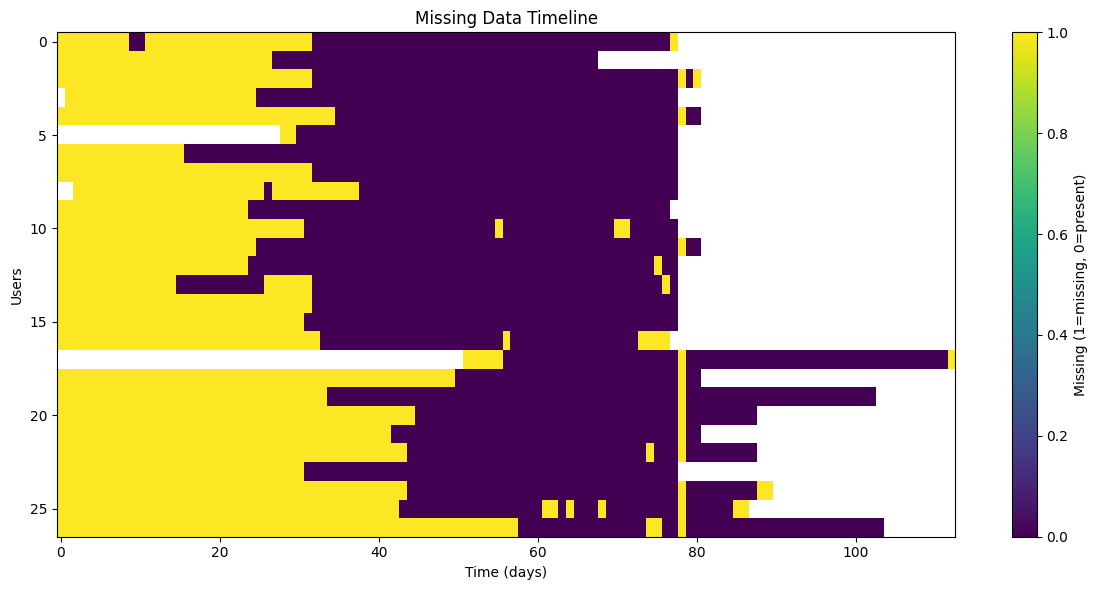

In [14]:
missing_matrix = df_panel["mood"].isna().unstack(level=0).T.astype(float)
missing_array = np.ma.masked_invalid(missing_matrix.values)

plt.figure(figsize=(12, 6))
plt.imshow(missing_array, aspect="auto", interpolation="none", cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="Missing (1=missing, 0=present)")
plt.title("Missing Data Timeline")
plt.xlabel("Time (days)")
plt.ylabel("Users")
plt.tight_layout()
plt.show()


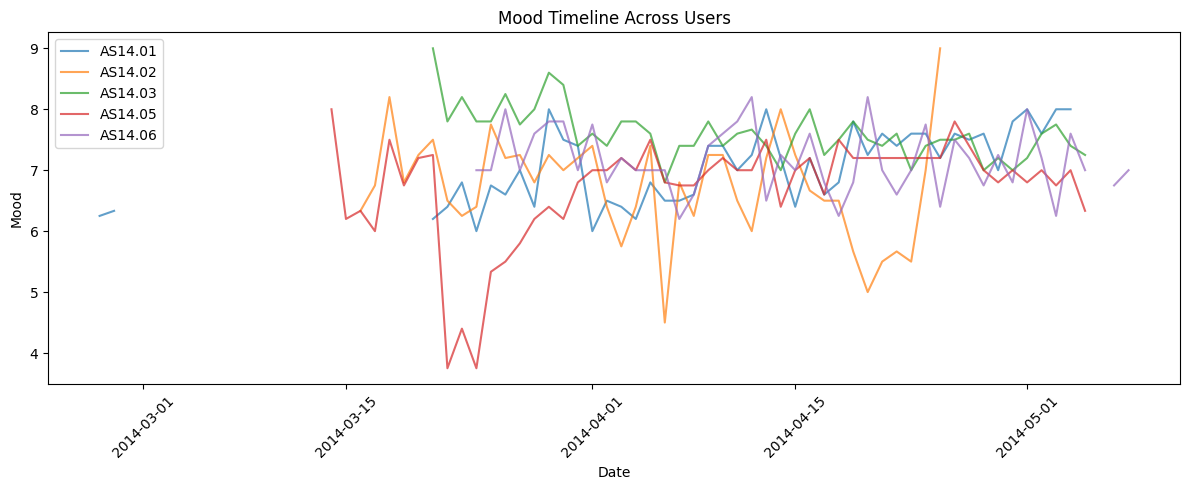

In [15]:
df_panel = df_panel.sort_index()

plt.figure(figsize=(12, 5))

for user in df_panel.index.get_level_values(0).unique()[:5]:  # limit to 5 users for clarity
    user_df = df_panel.loc[user]
    plt.plot(user_df.index, user_df["mood"], alpha=0.7, label=user)

plt.title("Mood Timeline Across Users")
plt.xlabel("Date")
plt.ylabel("Mood")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
key_cols = ["mood", "activity", "circumplex.arousal", "circumplex.valence"]  # adjust based on your dataset

df_panel["is_missing_day"] = df_panel[key_cols].isna().all(axis=1)

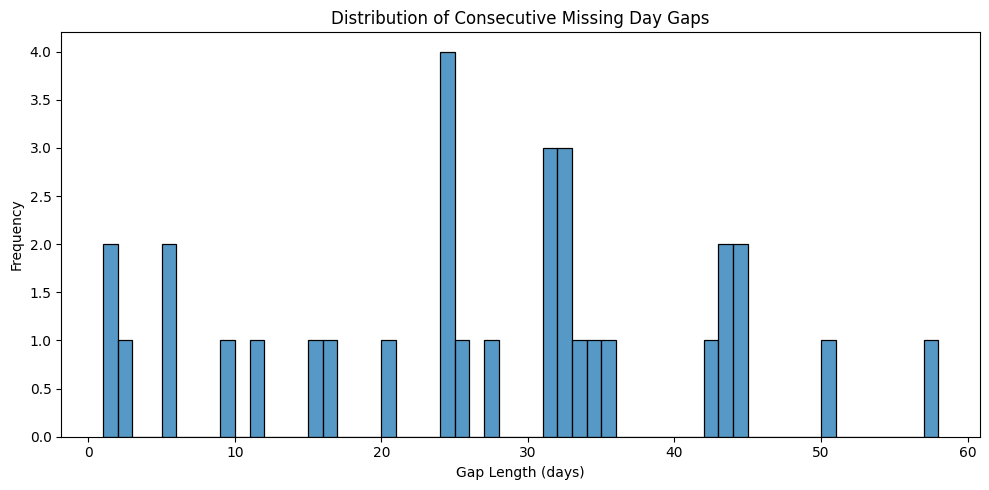

In [17]:
def compute_gap_lengths(group):
    missing = group["is_missing_day"].values

    gaps = []
    count = 0

    for m in missing:
        if m:
            count += 1
        else:
            if count > 0:
                gaps.append(count)
            count = 0

    if count > 0:
        gaps.append(count)

    return gaps

gap_lengths = df_panel.groupby(level=0).apply(compute_gap_lengths)
all_gaps = [gap for sublist in gap_lengths for gap in sublist]
plt.figure(figsize=(10, 5))
sns.histplot(all_gaps, bins=range(1, max(all_gaps) + 1), kde=False)
plt.title("Distribution of Consecutive Missing Day Gaps")
plt.xlabel("Gap Length (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [18]:
threshold = 3

big_gaps = [g for g in all_gaps if g > threshold]

print("Total gaps:", len(all_gaps))
print("Big gaps (>3 days):", len(big_gaps))
print("Max gap length:", max(all_gaps))

Total gaps: 32
Big gaps (>3 days): 29
Max gap length: 58


In [19]:
df_interp = df_panel.groupby(level=0, group_keys=False).apply(
    lambda x: x.interpolate(limit=3, limit_direction='both')
)

df_final = df_interp.groupby(level=0).transform(lambda x: x.fillna(x.mean()))

print("Final dataset shape:", df_final.shape)
display(df_final.head())


Final dataset shape: (2154, 39)


activity  circumplex.arousal  circumplex.valence  \
id      date                                                           
AS14.01 2014-02-17  0.089929           -0.211988            0.662865   
        2014-02-18  0.089929           -0.211988            0.662865   
        2014-02-19  0.089929           -0.211988            0.662865   
        2014-02-20  0.089929           -0.211988            0.662865   
        2014-02-21  0.089929           -0.211988            0.662865   

                        mood  appCat.builtin  appCat.communication  \
id      date                                                         
AS14.01 2014-02-17  6.952339             0.0                   0.0   
        2014-02-18  6.952339             0.0                   0.0   
        2014-02-19  6.952339             0.0                   0.0   
        2014-02-20  6.952339             0.0                   0.0   
        2014-02-21  6.952339             0.0                   0.0   

                    appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

                    appCat.office  ...  appCat.other_was_missing  \
id      date                       ...                             
AS14.01 2014-02-17            0.0  ...                         0   
        2014-02-18            0.0  ...                         0   
        2014-02-19            0.0  ...                         0   
        2014-02-20            0.0  ...                         0   
        2014-02-21            0.0  ...                         0   

                    appCat.social_was_missing  appCat.travel_was_missing  \
id      date                                                               
AS14.01 2014-02-17                          0                          0   
        2014-02-18                          0                          0   
        2014-02-19                          0                          0   
        2014-02-20                          0                          0   
        2014-02-21                          0                          0   

                    appCat.unknown_was_missing  appCat.utilities_was_missing  \
id      date                                                                   
AS14.01 2014-02-17                           0                             0   
        2014-02-18                           0                             0   
        2014-02-19                           0                             0   
        2014-02-20                           0                             0   
        2014-02-21                           0                             0   

                    appCat.weather_was_missing  call_was_missing  \
id      date                                                       
AS14.01 2014-02-17                           0                 0   
        2014-02-18                           0                 0   
        2014-02-19                           0                 0   
        2014-02-20                           0                 0   
        2014-02-21                           0                 0   

                    screen_was_missing  sms_was_missing  is_missing_day  
id      date                                                             
AS14.01 2014-02-17                   0                0            True  
        2014-02-18                   0                0            True  
        2014-02-19                   0                0            True  
        2014-02-20                   0                0            True  
        2014-02-21  

In [20]:
print("Remaining missing values:")
print(df_final.isna().sum().sort_values(ascending=False).head(20))

Remaining missing values:
activity                            0
appCat.other_was_missing            0
mood_was_missing                    0
appCat.builtin_was_missing          0
appCat.communication_was_missing    0
appCat.entertainment_was_missing    0
appCat.finance_was_missing          0
appCat.game_was_missing             0
appCat.office_was_missing           0
appCat.social_was_missing           0
circumplex.arousal_was_missing      0
appCat.travel_was_missing           0
appCat.unknown_was_missing          0
appCat.utilities_was_missing        0
appCat.weather_was_missing          0
call_was_missing                    0
screen_was_missing                  0
sms_was_missing                     0
circumplex.valence_was_missing      0
activity_was_missing                0
dtype: int64


In [21]:
print("Unique users:", df_final.index.get_level_values(0).nunique())
print("Date range:", df_final.index.get_level_values(1).min(), "→", df_final.index.get_level_values(1).max())

Unique users: 27
Date range: 2014-02-17 00:00:00 → 2014-06-09 00:00:00


In [22]:
before_na = df_panel.isna().sum().sum()
after_na = df_final.isna().sum().sum()

print("Before:", before_na)
print("After:", after_na)
print("Reduction:", before_na - after_na)

Before: 6341
After: 0
Reduction: 6341


In [23]:
df_final = df_final.sort_index()

mask = (
    ~df_final.columns.str.endswith("_was_missing")
    & (df_final.columns != "is_missing_day")
)

final_cols = df_final.columns[mask]

print("Final columns for modeling:", final_cols.tolist())

df_final = df_final[final_cols].copy()

display(df_final.head())

Final columns for modeling: ['activity', 'circumplex.arousal', 'circumplex.valence', 'mood', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'screen', 'sms']


activity  circumplex.arousal  circumplex.valence  \
id      date                                                           
AS14.01 2014-02-17  0.089929           -0.211988            0.662865   
        2014-02-18  0.089929           -0.211988            0.662865   
        2014-02-19  0.089929           -0.211988            0.662865   
        2014-02-20  0.089929           -0.211988            0.662865   
        2014-02-21  0.089929           -0.211988            0.662865   

                        mood  appCat.builtin  appCat.communication  \
id      date                                                         
AS14.01 2014-02-17  6.952339             0.0                   0.0   
        2014-02-18  6.952339             0.0                   0.0   
        2014-02-19  6.952339             0.0                   0.0   
        2014-02-20  6.952339             0.0                   0.0   
        2014-02-21  6.952339             0.0                   0.0   

                    appCat.entertainment  appCat.finance  appCat.game  \
id      date                                                            
AS14.01 2014-02-17                   0.0             0.0          0.0   
        2014-02-18                   0.0             0.0          0.0   
        2014-02-19                   0.0             0.0          0.0   
        2014-02-20                   0.0             0.0          0.0   
        2014-02-21                   0.0             0.0          0.0   

                    appCat.office  appCat.other  appCat.social  appCat.travel  \
id      date                                                                    
AS14.01 2014-02-17            0.0           0.0            0.0            0.0   
        2014-02-18            0.0           0.0            0.0            0.0   
        2014-02-19            0.0           0.0            0.0            0.0   
        2014-02-20            0.0           0.0            0.0            0.0   
        2014-02-21            0.0           0.0            0.0            0.0   

                    appCat.unknown  appCat.utilities  appCat.weather  call  \
id      date                                                                 
AS14.01 2014-02-17             0.0               0.0             0.0   2.0   
        2014-02-18             0.0               0.0             0.0   1.0   
        2014-02-19             0.0               0.0             0.0   7.0   
        2014-02-20             0.0               0.0             0.0   2.0   
        2014-02-21             0.0               0.0             0.0   0.0   

                    screen  sms  
id      date                     
AS14.01 2014-02-17     0.0  0.0  
        2014-02-18     0.0  0.0  
        2014-02-19     0.0  2.0  
        2014-02-20     0.0  3.0  
        2014-02-21     0.0  1.0

## Task 1C: Feature Engineering

In [24]:
df_tem = df_final.copy()
df_tem['mood_next_day'] = df_tem.groupby(level=0)['mood'].shift(-1)
df_tem = df_tem.dropna(subset=['mood_next_day'])


features = [
    'activity', 'circumplex.arousal', 'circumplex.valence', 'mood',
    'appCat.builtin', 'appCat.communication', 'appCat.entertainment',
    'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other',
    'appCat.social', 'appCat.travel', 'appCat.unknown',
    'appCat.utilities', 'appCat.weather', 'call', 'screen', 'sms',
]


<Axes: >

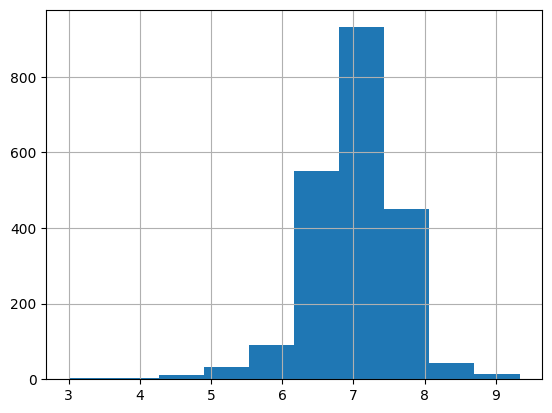

In [25]:
df_tem['mood_next_day'].hist()

In [26]:
def mood_to_class(m):
    # if m <= 6:
    #     return 0  # low
    # elif m <= 7.5:
    #     return 1  # medium
    # else:
    #     return 2  # high
    if m <= 4:
        return 0  # low
    elif m <= 7:
        return 1  # medium
    else:
        return 2  # high

df_tem['target'] = df_tem['mood_next_day'].apply(mood_to_class)

In [27]:
def create_sequences_with_user(df, features, target, window=5):
    X, y, users = [], [], []

    for user_id in df.index.get_level_values(0).unique():
        user_df = df.loc[user_id].sort_index()

        values = user_df[features].values
        targets = user_df[target].values

        for i in range(len(user_df) - window):
            X.append(values[i:i+window])
            y.append(targets[i+window])
            users.append(user_id)

    return np.array(X), np.array(y), np.array(users)

X, y, user_ids = create_sequences_with_user(df_tem, features, 'target', window=5)

print(X.shape)  # (samples, 5, features)

(1992, 5, 19)


In [28]:
test_user = np.unique(user_ids)[0]

train_mask = user_ids != test_user
test_mask = user_ids == test_user

X_seen_users, X_unseen_user = X[train_mask], X[test_mask]
y_seen_users, y_unseen_user = y[train_mask], y[test_mask]

df_final_reset = df_final.reset_index()

train_users = df_final_reset[df_final_reset["id"] != test_user]
test_users  = df_final_reset[df_final_reset["id"] == test_user]

print("Train users:", train_users["id"].nunique())
print("Test users:", test_users["id"].nunique())

# temporal split inside training users
train_users = train_users.sort_values("date")

split = int(0.8 * len(train_users))

train_df = train_users.iloc[:split]
test_df   = train_users.iloc[split:]

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

drop_cols = ["id", "date", "target", "mood_next_day", "mood"]

split = int(0.8 * len(X_seen_users))

X_train, X_test = X_seen_users[:split], X_seen_users[split:]
y_train, y_test = y_seen_users[:split], y_seen_users[split:]

Train users: 26
Test users: 1
Train shape: (1660, 21)
Test shape: (416, 21)


In [29]:
scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_unseen_reshaped = X_unseen_user.reshape(-1, X_unseen_user.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)
X_unseen_scaled = scaler.transform(X_unseen_reshaped)

X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)
X_unseen_user = X_unseen_scaled.reshape(X_unseen_user.shape)

In [30]:
import torch
import torch.nn as nn

class MoodLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_classes=3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])
        return self.fc(out)

Epoch 2, Train Loss: 1.0850, Val Loss: 1.0673
Epoch 4, Train Loss: 1.0651, Val Loss: 1.0656
Epoch 6, Train Loss: 1.0439, Val Loss: 1.0641
Epoch 8, Train Loss: 1.0342, Val Loss: 1.0629
Epoch 10, Train Loss: 1.0150, Val Loss: 1.0617
Epoch 12, Train Loss: 0.9904, Val Loss: 1.0604
Epoch 14, Train Loss: 0.9852, Val Loss: 1.0594
Epoch 16, Train Loss: 0.9572, Val Loss: 1.0585
Epoch 18, Train Loss: 0.9419, Val Loss: 1.0577
Epoch 20, Train Loss: 0.9228, Val Loss: 1.0569
Epoch 22, Train Loss: 0.9119, Val Loss: 1.0563
Epoch 24, Train Loss: 0.8852, Val Loss: 1.0554
Epoch 26, Train Loss: 0.8654, Val Loss: 1.0541
Epoch 28, Train Loss: 0.8514, Val Loss: 1.0513
Epoch 30, Train Loss: 0.8276, Val Loss: 1.0464
Epoch 32, Train Loss: 0.8148, Val Loss: 1.0386
Epoch 34, Train Loss: 0.8083, Val Loss: 1.0274
Epoch 36, Train Loss: 0.7797, Val Loss: 1.0122
Epoch 38, Train Loss: 0.7606, Val Loss: 0.9929
Epoch 40, Train Loss: 0.7303, Val Loss: 0.9697
Epoch 42, Train Loss: 0.7154, Val Loss: 0.9431
Epoch 44, Train L

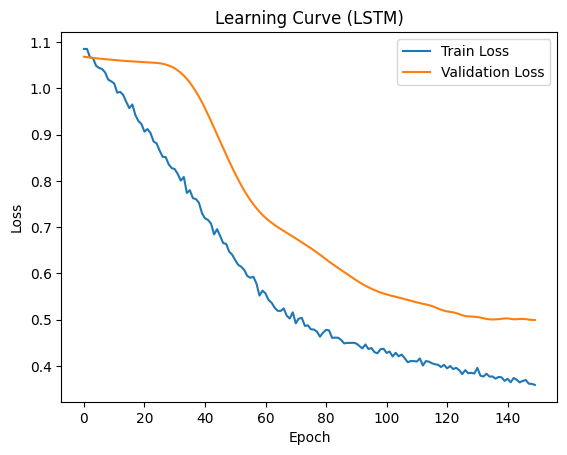

              precision    recall  f1-score   support

           1       0.80      0.63      0.70       188
           2       0.70      0.85      0.77       196

    accuracy                           0.74       384
   macro avg       0.75      0.74      0.74       384
weighted avg       0.75      0.74      0.74       384

Accuracy: 0.7421875


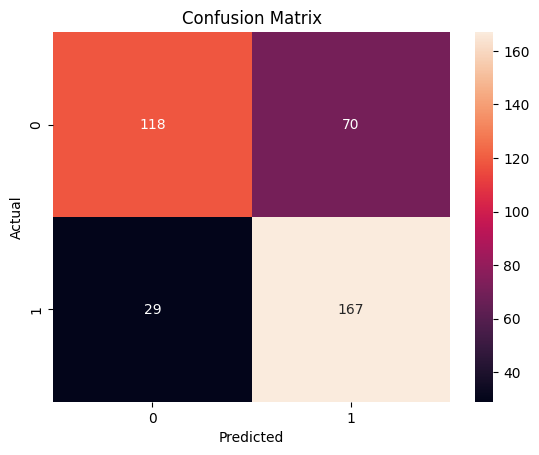

Unseen user evaluation:
              precision    recall  f1-score   support

           1       0.70      0.89      0.79        47
           2       0.58      0.28      0.38        25

    accuracy                           0.68        72
   macro avg       0.64      0.59      0.58        72
weighted avg       0.66      0.68      0.64        72

Accuracy: 0.6805555555555556


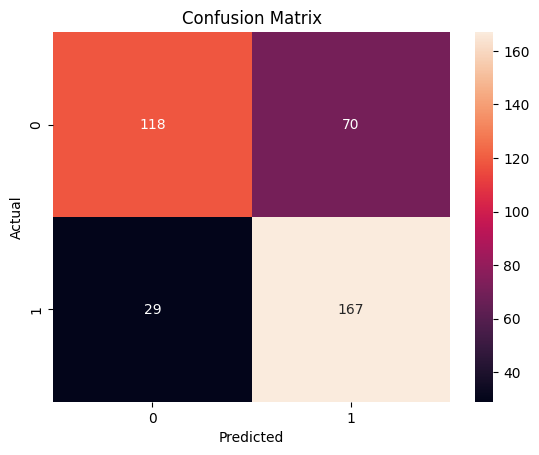

In [31]:
model_clf_lstm = MoodLSTM(input_size=X.shape[2])

weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
weights = torch.tensor(weights, dtype=torch.float32)

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = torch.optim.Adam(model_clf_lstm.parameters(), lr=0.001)

train_losses = []
val_losses = []

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_test, dtype=torch.float32)
y_val_t = torch.tensor(y_test, dtype=torch.long)

for epoch in range(150):
    model_clf_lstm.train()

    outputs = model_clf_lstm(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    model_clf_lstm.eval()
    with torch.no_grad():
        val_outputs = model_clf_lstm(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

    val_losses.append(val_loss.item())

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve (LSTM)")
plt.legend()
plt.show()

model_clf_lstm.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    preds = model_clf_lstm(X_test_t)
    preds = torch.argmax(preds, dim=1).numpy()

print(classification_report(y_test, preds))
print("Accuracy:", (preds == y_test).mean())

cm = confusion_matrix(y_test, preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("Unseen user evaluation:")
X_unseen_t = torch.tensor(X_unseen_user, dtype=torch.float32)
with torch.no_grad():
    unseen_preds = model_clf_lstm(X_unseen_t)
    unseen_preds = torch.argmax(unseen_preds, dim=1).numpy()
print(classification_report(y_unseen_user, unseen_preds))
print("Accuracy:", (unseen_preds == y_unseen_user).mean())
cm_unseen = confusion_matrix(y_unseen_user, unseen_preds)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
X, y, user_ids = create_sequences_with_user(df_tem, features, 'target', window=5)
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

test_user = np.unique(user_ids)[0]

train_mask = user_ids != test_user
test_mask = user_ids == test_user

X_seen_users, X_unseen_user = X[train_mask], X[test_mask]
y_seen_users, y_unseen_user = y[train_mask], y[test_mask]

split = int(0.8 * len(X_seen_users))

X_train, X_test = X_seen_users[:split], X_seen_users[split:]
y_train, y_test = y_seen_users[:split], y_seen_users[split:]

In [33]:
scaler = StandardScaler()

X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])

X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
X_unseen_reshaped = X_unseen_user.reshape(-1, X_unseen_user.shape[-1])

X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_test_scaled = scaler.transform(X_test_reshaped)
X_unseen_scaled = scaler.transform(X_unseen_reshaped)

X_train = X_train_scaled.reshape(X_train.shape)
X_test = X_test_scaled.reshape(X_test.shape)
X_unseen_user = X_unseen_scaled.reshape(X_unseen_user.shape)

y_train = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test = scaler.transform(y_test.reshape(-1, 1)).flatten()
y_unseen_user = scaler.transform(y_unseen_user.reshape(-1, 1)).flatten()

In [34]:
class MoodLSTMReg(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])
        return self.fc(out).squeeze()

Epoch 2, Train Loss: 1.0170, Val Loss: 1.0674
Epoch 4, Train Loss: 0.9950, Val Loss: 1.0529
Epoch 6, Train Loss: 0.9822, Val Loss: 1.0397
Epoch 8, Train Loss: 0.9712, Val Loss: 1.0277
Epoch 10, Train Loss: 0.9546, Val Loss: 1.0166
Epoch 12, Train Loss: 0.9416, Val Loss: 1.0066
Epoch 14, Train Loss: 0.9306, Val Loss: 0.9974
Epoch 16, Train Loss: 0.9163, Val Loss: 0.9887
Epoch 18, Train Loss: 0.9074, Val Loss: 0.9801
Epoch 20, Train Loss: 0.8860, Val Loss: 0.9715
Epoch 22, Train Loss: 0.8758, Val Loss: 0.9631
Epoch 24, Train Loss: 0.8586, Val Loss: 0.9554
Epoch 26, Train Loss: 0.8489, Val Loss: 0.9484
Epoch 28, Train Loss: 0.8381, Val Loss: 0.9421
Epoch 30, Train Loss: 0.8218, Val Loss: 0.9370
Epoch 32, Train Loss: 0.8099, Val Loss: 0.9327
Epoch 34, Train Loss: 0.7945, Val Loss: 0.9290
Epoch 36, Train Loss: 0.7967, Val Loss: 0.9244
Epoch 38, Train Loss: 0.7811, Val Loss: 0.9184
Epoch 40, Train Loss: 0.7734, Val Loss: 0.9099
Epoch 42, Train Loss: 0.7696, Val Loss: 0.8971
Epoch 44, Train L

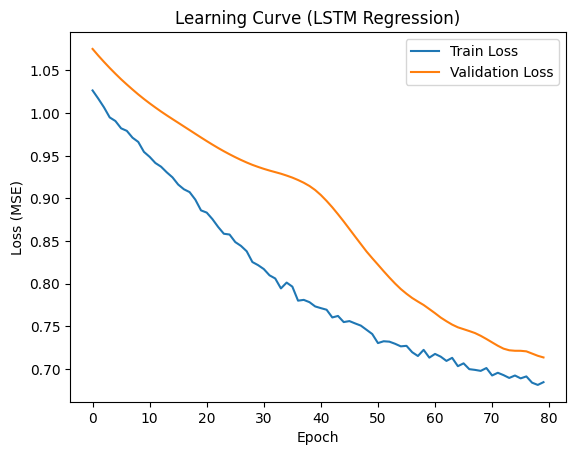

MSE: 0.17856254172971628
MAE: 0.3411942971870303
Unseen user evaluation:
Unseen User MSE: 0.16111828357046976
Unseen User MAE: 0.3636782806780603


In [35]:
# Initialize model
model_reg_lstm = MoodLSTMReg(input_size=X.shape[2])

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_reg_lstm.parameters(), lr=0.001)

train_losses = []
val_losses = []

# Convert to tensors (FLOAT!)
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_test, dtype=torch.float32)
y_val_t = torch.tensor(y_test, dtype=torch.float32)

# Training loop
for epoch in range(80):
    model_reg_lstm.train()

    outputs = model_reg_lstm(X_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Validation
    model_reg_lstm.eval()
    with torch.no_grad():
        val_outputs = model_reg_lstm(X_val_t)
        val_loss = criterion(val_outputs, y_val_t)

    val_losses.append(val_loss.item())

    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")


plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Learning Curve (LSTM Regression)")
plt.legend()
plt.show()

model_reg_lstm.eval()

X_test_t = torch.tensor(X_test, dtype=torch.float32)

with torch.no_grad():
    preds = model_reg_lstm(X_test_t).numpy()

preds = y_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
y_test_real = y_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_test_real, preds)
mae = mean_absolute_error(y_test_real, preds)

print("MSE:", mse)
print("MAE:", mae)

print("Unseen user evaluation:")
X_unseen_t = torch.tensor(X_unseen_user, dtype=torch.float32)

with torch.no_grad():
    unseen_preds = model_reg_lstm(X_unseen_t).numpy()

unseen_preds = y_scaler.inverse_transform(unseen_preds.reshape(-1, 1)).flatten()
y_unseen_real = y_scaler.inverse_transform(y_unseen_user.reshape(-1, 1)).flatten()

unseen_mse = mean_squared_error(y_unseen_real, unseen_preds)
unseen_mae = mean_absolute_error(y_unseen_real, unseen_preds)

print("Unseen User MSE:", unseen_mse)
print("Unseen User MAE:", unseen_mae)

## Non Temporal Models

In [36]:
df_ml = df_final.copy()
df_ml['mood_next_day'] = df_ml.groupby(level=0)['mood'].shift(-1)
df_ml = df_ml.dropna(subset=['mood_next_day'])

In [37]:
def mood_to_class(m):
    if m <= 4:
        return 0  # low
    elif m <= 7:
        return 1  # medium
    else:
        return 2  # high

# Classification target for the engineered feature set
df_ml['target'] = df_ml['mood_next_day'].apply(mood_to_class)

feature_cols = [col for col in df_ml.columns if col not in ['mood_next_day', 'target']]
print('engineered feature count:', len(feature_cols))
print(df_ml['target'].value_counts())


engineered feature count: 19
target
1    1214
2     906
0       7
Name: count, dtype: int64


In [38]:
cont_features = [
    'activity', 'circumplex.arousal', 'circumplex.valence', 'mood',
    'screen',
    'appCat.builtin', 'appCat.communication', 'appCat.entertainment',
    'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other',
    'appCat.social', 'appCat.travel', 'appCat.unknown',
    'appCat.utilities', 'appCat.weather'
]
count_features = ['call', 'sms']

In [39]:
df_ml = df_ml.reset_index()
df_ml = df_ml.sort_values(["id", "date"])
g = df_ml.groupby("id")
WINDOW = 5

def compute_trend(x):
    if len(x) < 2:
        return 0
    return np.polyfit(np.arange(len(x)), x, 1)[0]

feature_blocks = []

for col in cont_features:
    roll = g[col].rolling(WINDOW)

    block = pd.DataFrame({
        f"{col}_mean":  roll.mean().droplevel(0).shift(1),
        f"{col}_std":   roll.std().droplevel(0).shift(1),
        f"{col}_min":   roll.min().droplevel(0).shift(1),
        f"{col}_max":   roll.max().droplevel(0).shift(1),
        f"{col}_last":  g[col].shift(1),
        f"{col}_trend": roll.apply(compute_trend, raw=True).droplevel(0).shift(1),
    })
    feature_blocks.append(block)

for col in count_features:
    roll = g[col].rolling(WINDOW)

    block = pd.DataFrame({
        f"{col}_sum":  roll.sum().droplevel(0).shift(1),
        f"{col}_mean": roll.mean().droplevel(0).shift(1),
        f"{col}_last": g[col].shift(1),
    })
    feature_blocks.append(block)

features_df = pd.concat(feature_blocks, axis=1)

df_features = pd.concat([df_ml, features_df], axis=1)
df_ml_features = df_features.dropna()

In [40]:
df_ml_features.head()

,id,date,activity,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,...,appCat.weather_min,appCat.weather_max,appCat.weather_last,appCat.weather_trend,call_sum,call_mean,call_last,sms_sum,sms_mean,sms_last
5,AS14.01,2014-02-22,0.089929,-0.211988,0.662865,6.952339,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.000000,2.400000,0.000000,6.000000,1.200000,1.000000
6,AS14.01,2014-02-23,0.089929,-0.250000,0.750000,6.250000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,12.000000,2.400000,2.000000,7.000000,1.400000,1.000000
7,AS14.01,2014-02-24,0.089929,-0.250000,0.750000,6.250000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,13.333333,2.666667,2.333333,7.666667,1.533333,0.666667
8,AS14.01,2014-02-25,0.089929,-0.250000,0.750000,6.250000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,9.000000,1.800000,2.666667,6.000000,1.200000,0.333333
9,AS14.01,2014-02-26,0.089929,-0.250000,0.750000,6.250000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,10.000000,2.000000,3.000000,3.000000,0.600000,0.000000


In [41]:
df_ml_features["day_of_week"] = df_ml_features["date"].dt.dayofweek
df_ml_features["user_mean_mood"] = df_ml_features.groupby("id")["mood"].transform("mean")
df_ml_features["mood_dev"] = df_ml_features["mood"] - df_ml_features["user_mean_mood"]
df_ml_features["lag1_mood"] = df_ml_features.groupby("id")["mood"].shift(1)
df_ml_features["social_ratio"] = (
    df_ml_features["appCat.social"] / (df_ml_features["screen"] + 1e-5)
)
df_ml_features = df_ml_features.dropna()

/tmp/ipykernel_94208/282937425.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_features["day_of_week"] = df_ml_features["date"].dt.dayofweek
/tmp/ipykernel_94208/282937425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_features["user_mean_mood"] = df_ml_features.groupby("id")["mood"].transform("mean")
/tmp/ipykernel_94208/282937425.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

Se

In [42]:
df_ml_features.head()

,id,date,activity,circumplex.arousal,circumplex.valence,mood,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,...,call_mean,call_last,sms_sum,sms_mean,sms_last,day_of_week,user_mean_mood,mood_dev,lag1_mood,social_ratio
6,AS14.01,2014-02-23,0.089929,-0.25,0.750000,6.250000,0.0,0.0,0.0,0.0,...,2.400000,2.000000,7.000000,1.400000,1.000000,6,6.937788,-0.687788,6.952339,0.0
7,AS14.01,2014-02-24,0.089929,-0.25,0.750000,6.250000,0.0,0.0,0.0,0.0,...,2.666667,2.333333,7.666667,1.533333,0.666667,0,6.937788,-0.687788,6.250000,0.0
8,AS14.01,2014-02-25,0.089929,-0.25,0.750000,6.250000,0.0,0.0,0.0,0.0,...,1.800000,2.666667,6.000000,1.200000,0.333333,1,6.937788,-0.687788,6.250000,0.0
9,AS14.01,2014-02-26,0.089929,-0.25,0.750000,6.250000,0.0,0.0,0.0,0.0,...,2.000000,3.000000,3.000000,0.600000,0.000000,2,6.937788,-0.687788,6.250000,0.0
10,AS14.01,2014-02-27,0.089929,0.00,0.333333,6.333333,0.0,0.0,0.0,0.0,...,2.200000,1.000000,4.000000,0.800000,2.000000,3,6.937788,-0.604455,6.250000,0.0


In [44]:
df_ml_features = df_ml_features.sort_values(["date"])
test_user = df_ml_features["id"].sample(1).iloc[0]
print("Test user:", test_user)

train_users = df_ml_features[df_ml_features["id"] != test_user]
test_users  = df_ml_features[df_ml_features["id"] == test_user]

print("Train users:", train_users["id"].nunique())
print("Test users:", test_users["id"].nunique())

# temporal split inside training users
train_users = train_users.sort_values("date")

split = int(0.8 * len(train_users))

train_df = train_users.iloc[:split]
val_df   = train_users.iloc[split:]

print("Train shape:", train_df.shape)
print("Test shape:", val_df.shape)

drop_cols = ["id", "date", "target", "mood_next_day", "mood"]


X_train = train_df.drop(columns=drop_cols)
y_train = train_df["target"]
y_train_reg = train_df["mood_next_day"]

X_val = val_df.drop(columns=drop_cols)
y_val = val_df["target"]
y_val_reg = val_df["mood_next_day"]

X_test = test_users.drop(columns=drop_cols)
y_test = test_users["target"]
y_test_reg = test_users["mood_next_day"]

Test user: AS14.31
Train users: 26
Test users: 1
Train shape: (1505, 136)
Test shape: (377, 136)


In [45]:
def evaluate_model_clf(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    print(f"\n===== {name} RESULTS =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1-score (macro):", f1_score(y_test, y_pred, average="macro"))

    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    return y_pred


def evaluate_model_reg(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print(f"\n===== {name} RESULTS =====")
    print("MSE:", mse)
    print("MAE:", mae)

    plt.figure(figsize=(6,5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f"{name} - Predicted vs Actual")
    plt.xlabel("Actual Mood")
    plt.ylabel("Predicted Mood")
    plt.show()

    return y_pred




===== Random Forest RESULTS =====
Accuracy: 0.8072289156626506
F1-score (macro): 0.5015015015015015

Classification Report:

              precision    recall  f1-score   support

           1       0.89      0.89      0.89        74
           2       0.11      0.11      0.11         9

    accuracy                           0.81        83
   macro avg       0.50      0.50      0.50        83
weighted avg       0.81      0.81      0.81        83



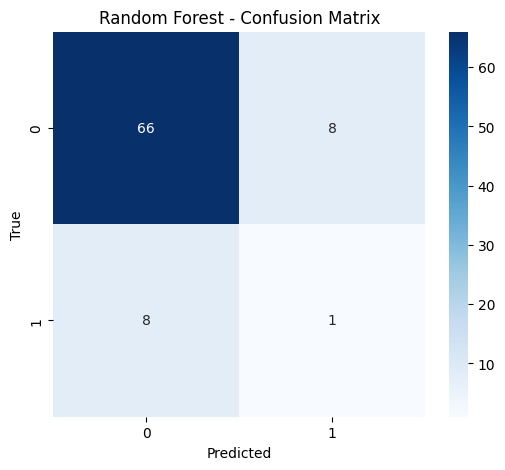

In [46]:
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = evaluate_model_clf(rf, X_test, y_test, "Random Forest")

[0]	validation_0-mlogloss:0.68387
[1]	validation_0-mlogloss:0.67606
[2]	validation_0-mlogloss:0.66576
[3]	validation_0-mlogloss:0.65976
[4]	validation_0-mlogloss:0.65574
[5]	validation_0-mlogloss:0.64845
[6]	validation_0-mlogloss:0.64442
[7]	validation_0-mlogloss:0.64195
[8]	validation_0-mlogloss:0.63760
[9]	validation_0-mlogloss:0.63551
[10]	validation_0-mlogloss:0.63344
[11]	validation_0-mlogloss:0.62968
[12]	validation_0-mlogloss:0.62723
[13]	validation_0-mlogloss:0.62709
[14]	validation_0-mlogloss:0.62495
[15]	validation_0-mlogloss:0.62328
[16]	validation_0-mlogloss:0.62202
[17]	validation_0-mlogloss:0.61810
[18]	validation_0-mlogloss:0.61658
[19]	validation_0-mlogloss:0.61558
[20]	validation_0-mlogloss:0.61437
[21]	validation_0-mlogloss:0.61246
[22]	validation_0-mlogloss:0.61075
[23]	validation_0-mlogloss:0.60877
[24]	validation_0-mlogloss:0.60725
[25]	validation_0-mlogloss:0.60567
[26]	validation_0-mlogloss:0.60476
[27]	validation_0-mlogloss:0.60330
[28]	validation_0-mlogloss:0.6

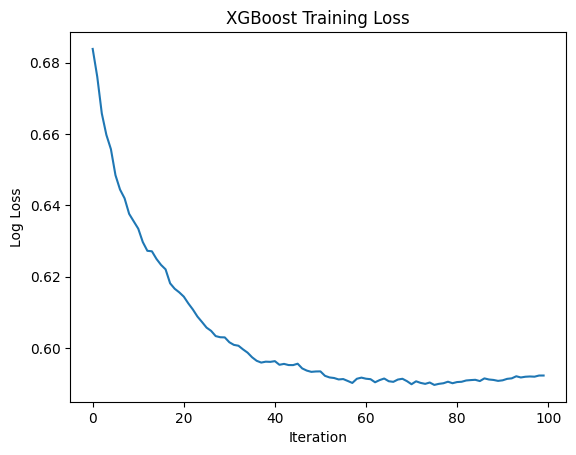


===== XGBoost RESULTS =====
Accuracy: 0.8554216867469879
F1-score (macro): 0.7077464788732395

Classification Report:

              precision    recall  f1-score   support

           1       0.96      0.88      0.92        74
           2       0.40      0.67      0.50         9

    accuracy                           0.86        83
   macro avg       0.68      0.77      0.71        83
weighted avg       0.90      0.86      0.87        83



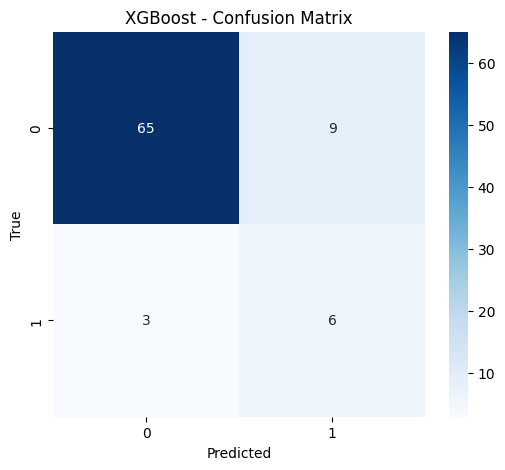

In [48]:
xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",   # change to "binary:logistic" if binary
    num_class=len(np.unique(y_train)),
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

results = xgb.evals_result()

plt.plot(results["validation_0"]["mlogloss"])
plt.title("XGBoost Training Loss")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.show()

xgb_pred = evaluate_model_clf(xgb, X_test, y_test, "XGBoost")


===== Logistic Regression RESULTS =====
Accuracy: 0.7469879518072289
F1-score (macro): 0.505531914893617

Classification Report:

              precision    recall  f1-score   support

           1       0.90      0.81      0.85        74
           2       0.12      0.22      0.16         9

    accuracy                           0.75        83
   macro avg       0.51      0.52      0.51        83
weighted avg       0.81      0.75      0.78        83



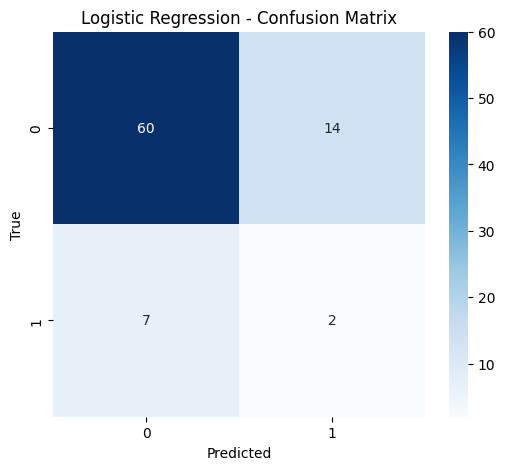

In [50]:
log_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=150,
        class_weight="balanced",
        solver="lbfgs"
    ))
])

log_reg.fit(X_train, y_train)
lr_pred = evaluate_model_clf(log_reg, X_test, y_test, "Logistic Regression")


===== Random Forest Regression RESULTS =====
MSE: 0.07002020108493474
MAE: 0.16049284643554657


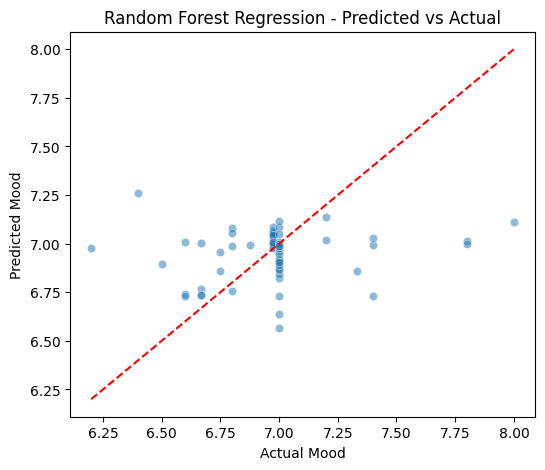

In [53]:
rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train_reg)

rf_pred = evaluate_model_reg(rf, X_test, y_test_reg, "Random Forest Regression")

[0]	validation_0-rmse:0.72841
[1]	validation_0-rmse:0.72433
[2]	validation_0-rmse:0.71681
[3]	validation_0-rmse:0.70973
[4]	validation_0-rmse:0.70284
[5]	validation_0-rmse:0.69849
[6]	validation_0-rmse:0.69345
[7]	validation_0-rmse:0.68747
[8]	validation_0-rmse:0.68041
[9]	validation_0-rmse:0.67321
[10]	validation_0-rmse:0.66966
[11]	validation_0-rmse:0.66602
[12]	validation_0-rmse:0.66214
[13]	validation_0-rmse:0.65922
[14]	validation_0-rmse:0.65660
[15]	validation_0-rmse:0.65461
[16]	validation_0-rmse:0.65193
[17]	validation_0-rmse:0.65166
[18]	validation_0-rmse:0.65144
[19]	validation_0-rmse:0.65119
[20]	validation_0-rmse:0.64864
[21]	validation_0-rmse:0.64814
[22]	validation_0-rmse:0.64709
[23]	validation_0-rmse:0.64463
[24]	validation_0-rmse:0.64316
[25]	validation_0-rmse:0.64352
[26]	validation_0-rmse:0.64249
[27]	validation_0-rmse:0.64275
[28]	validation_0-rmse:0.64326
[29]	validation_0-rmse:0.64311
[30]	validation_0-rmse:0.64198
[31]	validation_0-rmse:0.64199
[32]	validation_0-

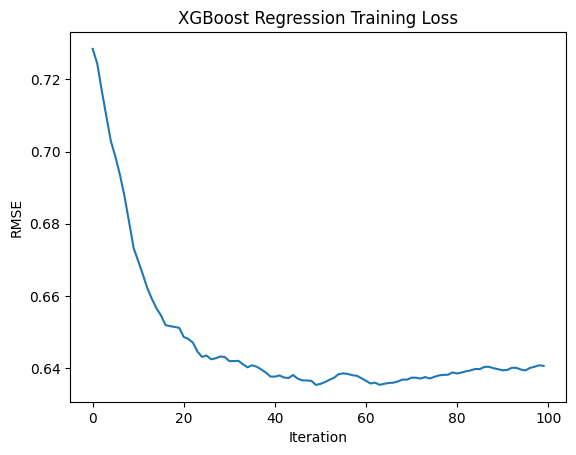


===== XGBoost Regression RESULTS =====
MSE: 0.07515052426339003
MAE: 0.16841137324598074


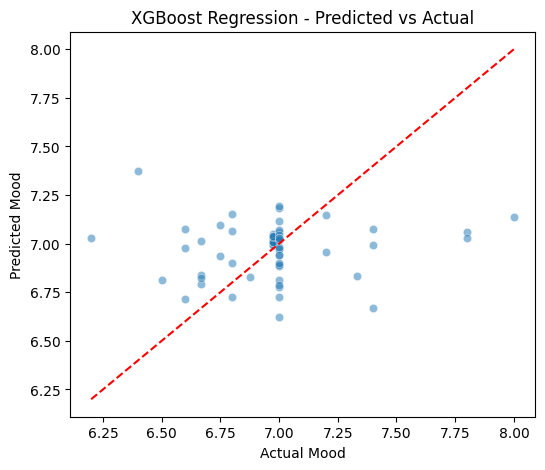

In [55]:
xgb_reg = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    eval_metric="rmse",
    n_jobs=-1
)

xgb_reg.fit(
    X_train,
    y_train_reg,
    eval_set=[(X_val, y_val_reg)],
    verbose=True
)

results = xgb_reg.evals_result()

plt.plot(results["validation_0"]["rmse"])
plt.title("XGBoost Regression Training Loss")
plt.xlabel("Iteration")
plt.ylabel("RMSE")
plt.show()

xgb_reg_pred = evaluate_model_reg(xgb_reg, X_test, y_test_reg, "XGBoost Regression")


===== Linear Regression RESULTS =====
MSE: 0.16863998103874733
MAE: 0.27755801734796254


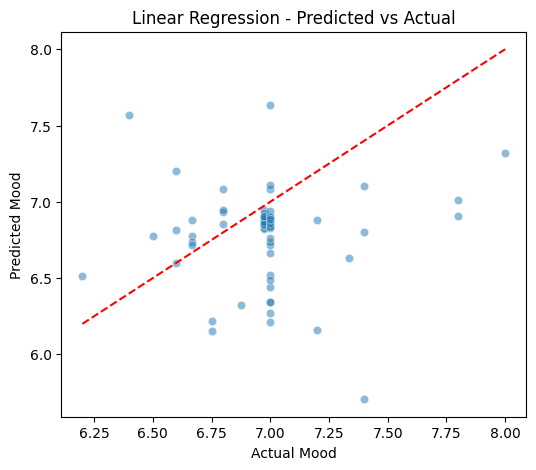

In [56]:
linear_reg = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_reg.fit(X_train, y_train_reg)
lr_pred = evaluate_model_reg(linear_reg, X_test, y_test_reg, "Linear Regression")